# Does the Federal Reserve's Beige Book Predict the Economy?

**A Sentiment Analysis of Regional Economic Narratives from the 12 Federal Reserve District Banks, 2011--2025**

---

Eight times per year, the Federal Reserve publishes the [Beige Book](https://www.federalreserve.gov/monetarypolicy/beige-book-default.htm) -- a compilation of qualitative economic summaries from each of its 12 district banks. These narratives, drawn from interviews with business contacts, community organizations, and other local sources, represent one of the few systematic attempts to capture economic conditions in real time through language rather than statistics. Yet despite their prominence in monetary policy deliberations, the question of whether these narratives contain information not already reflected in quantitative indicators remains largely open.

This study tests that question directly. We scrape 1,440 district-level summaries spanning 120 Beige Book reports (2011--2025), quantify the sentiment of each summary using VADER (Hutto and Gilbert, 2014), and evaluate whether those sentiment scores have **predictive power** for four macroeconomic indicators:

| FRED Series | Indicator | Frequency |
|-------------|-----------|-----------|
| `GDPC1` | Real Gross Domestic Product | Quarterly |
| `UNRATE` | Civilian Unemployment Rate | Monthly |
| `CPIAUCSL` | Consumer Price Index (All Urban Consumers) | Monthly |
| `SP500` | S&P 500 Index | Daily (monthly avg.) |

Our approach combines lagged correlation analysis, Granger causality tests, OLS regression with controls for each indicator's own autoregressive structure, and out-of-sample forecasting evaluation. We extend the national analysis to the regional level by correlating each district's sentiment with its primary state's Coincident Economic Activity Index, and we benchmark VADER against two transformer-based alternatives -- FinBERT-FOMC and FinBERT-Tone -- to assess whether model sophistication improves predictive accuracy.

The central finding is that Beige Book sentiment does carry genuine predictive content, but selectively: it Granger-causes unemployment at lags of 3--4 periods (p = 0.002) and GDP at lags of 1--2 periods (p = 0.001), while showing no predictive value for the S&P 500. Regionally, the Cleveland district stands out with a correlation of r = 0.66 between sentiment and state economic activity -- a result we attribute to Ohio's manufacturing-concentrated economy. Perhaps most counterintuitively, the simple rule-based VADER model outperforms both fine-tuned transformers in 10 of 12 districts, a finding that speaks to the importance of domain-baseline alignment over model complexity.

---

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.4f}".format)

## 1. Data Acquisition

The analysis draws on two complementary data sources. The first is the text of the Beige Book itself: we scrape all 120 reports published between January 2011 and November 2025 from the [Federal Reserve website](https://www.federalreserve.gov/monetarypolicy/), extracting the "Summary of Economic Activity" section for each of the 12 district banks. This yields 1,440 district-report observations. We restrict the sample to 2011 onward because earlier reports use an inconsistent HTML structure that complicates automated extraction.

The second source is the [FRED API](https://fred.stlouisfed.org/), from which we pull four macroeconomic time series: Real GDP (`GDPC1`, quarterly), the civilian unemployment rate (`UNRATE`, monthly), the Consumer Price Index for All Urban Consumers (`CPIAUCSL`, monthly), and the S&P 500 index (`SP500`, daily, averaged to monthly). These indicators span the real economy, the labor market, the price level, and financial markets, providing a broad surface against which to test the informational content of Beige Book narratives.

In [2]:
from src.acquire import get_beige_data, get_fred_data

beige_df = get_beige_data()
fred_df = get_fred_data()

print(f"Beige Book: {len(beige_df):,} rows | {beige_df['date'].nunique()} reports | {beige_df['district'].nunique()} districts")
print(f"Date range: {beige_df['date'].min():%Y-%m} to {beige_df['date'].max():%Y-%m}")
print(f"\nFRED indicators: {len(fred_df):,} rows | Columns: {', '.join(fred_df.columns[1:])}")
beige_df.head(3)

Beige Book: 1,464 rows | 122 reports | 12 districts
Date range: 2011-01 to 2026-02

FRED indicators: 315 rows | Columns: GDPC1, UNRATE, CPIAUCSL, SP500


,date,district,summary
0,2011-01-01,Boston,RetailThe majority of contacted First District...
1,2011-01-01,New York,Consumer SpendingVirtually all non-auto retail...
2,2011-01-01,Philadelphia,Most Third District business contacts foresee ...


## 2. Text Preparation

Raw Beige Book HTML contains formatting artifacts, inconsistent whitespace, and variant district names (e.g., "Federal Reserve Bank of St. Louis" vs. "St. Louis"). We clean the scraped text by stripping residual HTML tags, normalizing whitespace, and mapping all district name variants to 12 canonical short names defined in `src/config.py`. No stemming or stopword removal is applied at this stage, as VADER operates on raw text and benefits from the presence of modifiers and punctuation.

In [3]:
from src.prepare import prep_beige_data

beige_df = prep_beige_data(beige_df)

# Preview a sample summary
sample = beige_df[beige_df["district"] == "Boston"].iloc[0]
print(f"District: {sample['district']} | Date: {sample['date']:%Y-%m}")
print(f"Summary (first 300 chars):\n{sample['summary'][:300]}...")

District: Boston | Date: 2011-01
Summary (first 300 chars):
RetailThe majority of contacted First District retailers report positive sales results for the months of November and December. Year-over-year comparable same-store sales are mostly increases ranging from the low single digits to the low double digits, with the exception of one contact who reports a...


## 3. Sentiment Scoring

To quantify the tone of each district summary, we apply [VADER](https://github.com/cjhutto/vaderSentiment) (Valence Aware Dictionary and sEntiment Reasoner), a rule-based sentiment model developed by Hutto and Gilbert (2014). VADER maps each word in its 7,500-term lexicon to a valence score, then aggregates across the full text to produce a **compound score** on the interval [-1, +1], where -1 represents maximal negativity and +1 maximal positivity.

We choose VADER over alternatives for two reasons explored in detail in Section 8. First, it requires no training data or GPU infrastructure, making it reproducible and transparent. Second -- and less obviously -- its positive bias (mean compound score of 0.66 across all summaries) turns out to align well with the Beige Book's own tonal baseline: most summaries describe an economy that is growing, albeit at varying rates. This alignment means that deviations from VADER's positive default carry genuine informational content.

After scoring each of the 1,440 district summaries, we aggregate to the national level by computing the cross-district mean sentiment for each report date. This national aggregate is then aligned to FRED indicators using `merge_asof(direction='forward')`, which maps each Beige Book publication date to the next available indicator observation -- a forward-looking alignment that avoids look-ahead bias.

In [4]:
from src.sentiment import add_sentiment_scores

beige_df = add_sentiment_scores(beige_df)

print("Sentiment score distribution:")
beige_df["vader_compound"].describe().to_frame().T

Sentiment score distribution:


,count,mean,std,min,25%,50%,75%,max
vader_compound,1464.0000,0.6609,0.4939,-0.9969,0.5267,0.9118,0.9966,0.9997


In [5]:
from src.prepare import compute_national_aggregate, align_time_periods

national_df = compute_national_aggregate(beige_df)
merged_df = align_time_periods(national_df, fred_df)

print(f"National aggregates: {len(national_df)} report dates")
print(f"Merged with FRED: {len(merged_df)} rows")
merged_df[["date", "sentiment_mean", "GDPC1", "UNRATE", "CPIAUCSL", "SP500"]].head()

National aggregates: 122 report dates
Merged with FRED: 122 rows


,date,sentiment_mean,GDPC1,UNRATE,CPIAUCSL,SP500
0,2011-01-01,0.6870,16920.6320,9.1000,221.1870,NaN
1,2011-03-01,0.4877,NaN,9.0000,223.0460,NaN
2,2011-04-01,0.4621,17035.1140,9.1000,224.0930,NaN
3,2011-06-01,0.2394,NaN,9.1000,224.8060,NaN
4,2011-07-01,0.3645,17031.3130,9.0000,225.3950,NaN


## 4. Exploratory Analysis

Before proceeding to formal hypothesis tests, we examine the data visually to build intuition about the sentiment series and its relationship to macroeconomic indicators.

### National Sentiment Over Time

The time series of national mean sentiment reveals several notable features. The series exhibits a persistent positive level (consistent with the Beige Book's generally optimistic framing), punctuated by sharp downturns during periods of economic stress. The most dramatic decline occurs in early 2020, when COVID-19 drove sentiment to its lowest recorded values. The subsequent recovery was rapid but uneven across districts, a pattern we explore in the regional analysis below.

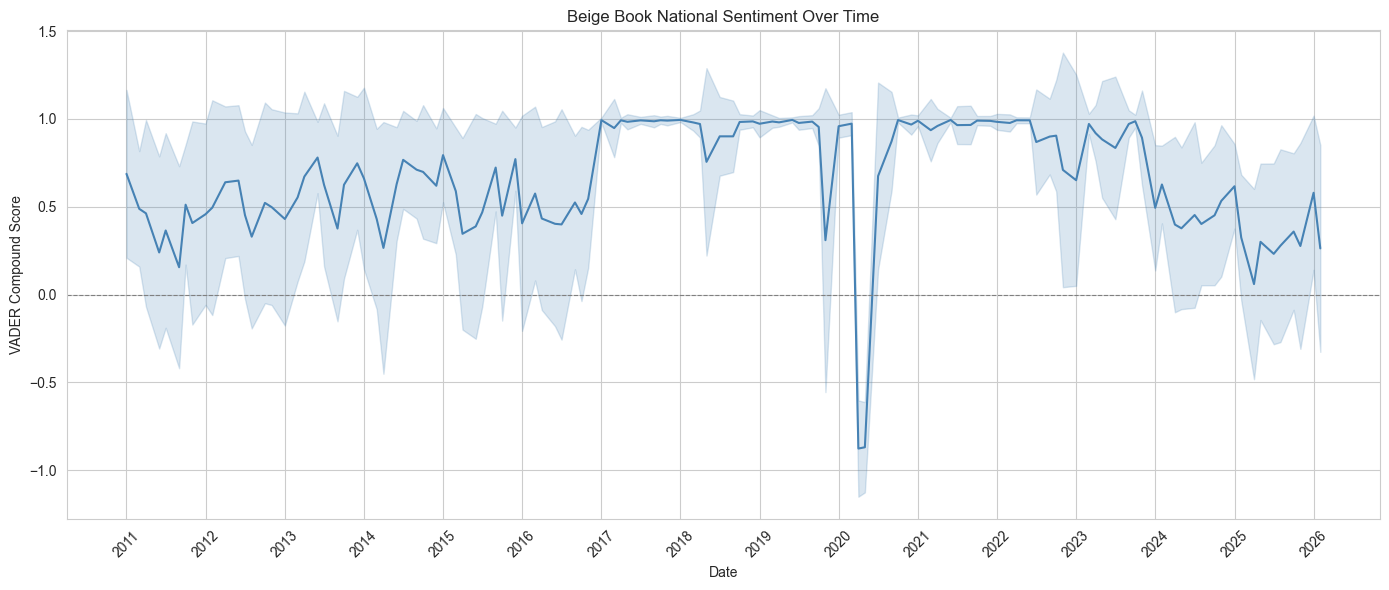

In [6]:
from src.explore import plot_sentiment_timeseries, plot_regional_comparison, plot_sentiment_vs_indicator

fig = plot_sentiment_timeseries(national_df, save=False)
plt.show()

### Regional Sentiment Heatmap

The heatmap below displays sentiment scores across all 12 districts over time, revealing both the degree of cross-district synchronization and the idiosyncratic variation that motivates the regional analysis in Section 7. Several patterns are immediately apparent: all districts share the COVID-era trough, but their baseline levels and volatilities differ substantially. Northeastern districts (Boston, New York, Philadelphia) tend to report higher sentiment than western districts, a geographic gradient that persists across nearly every time period in the sample.

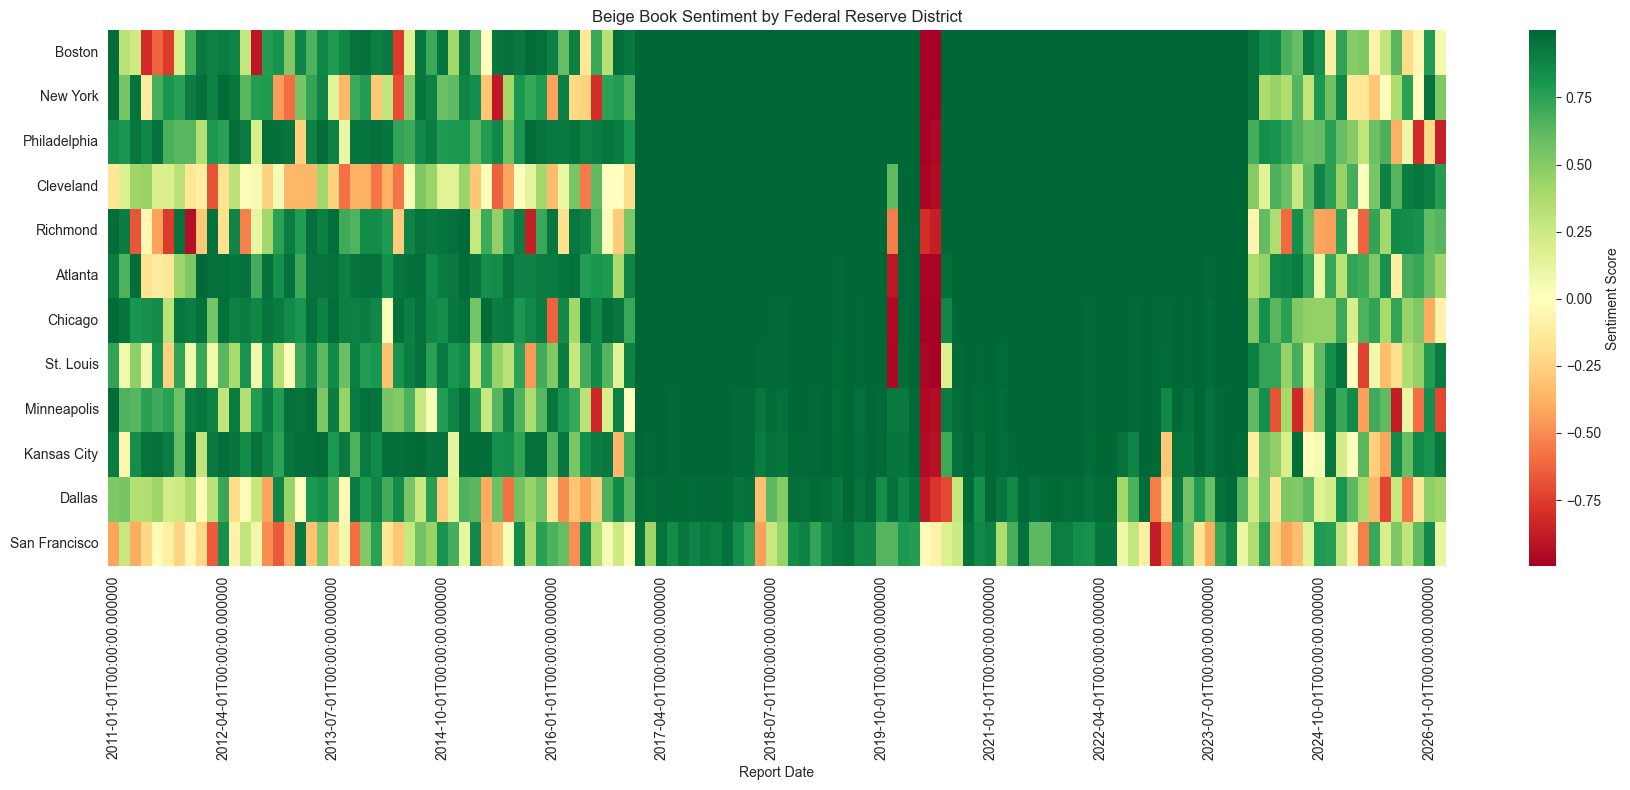

In [7]:
fig = plot_regional_comparison(beige_df, save=False)
plt.show()

### Sentiment vs. Economic Indicators

The dual-axis plots below overlay national mean sentiment against each of the four target indicators. Visual inspection suggests a strong inverse relationship with unemployment -- when sentiment rises, unemployment tends to fall in subsequent periods -- and a weaker, possibly contemporaneous relationship with GDP. The CPI and S&P 500 relationships are less clear from visual inspection alone, motivating the formal statistical tests that follow.

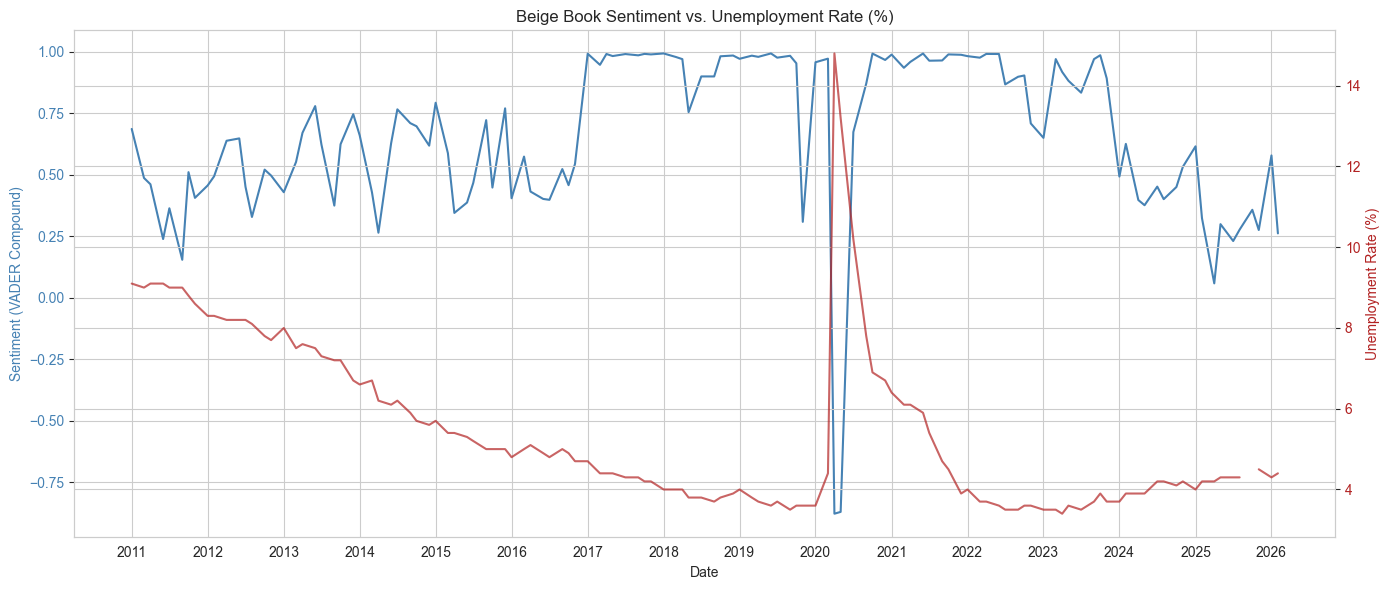

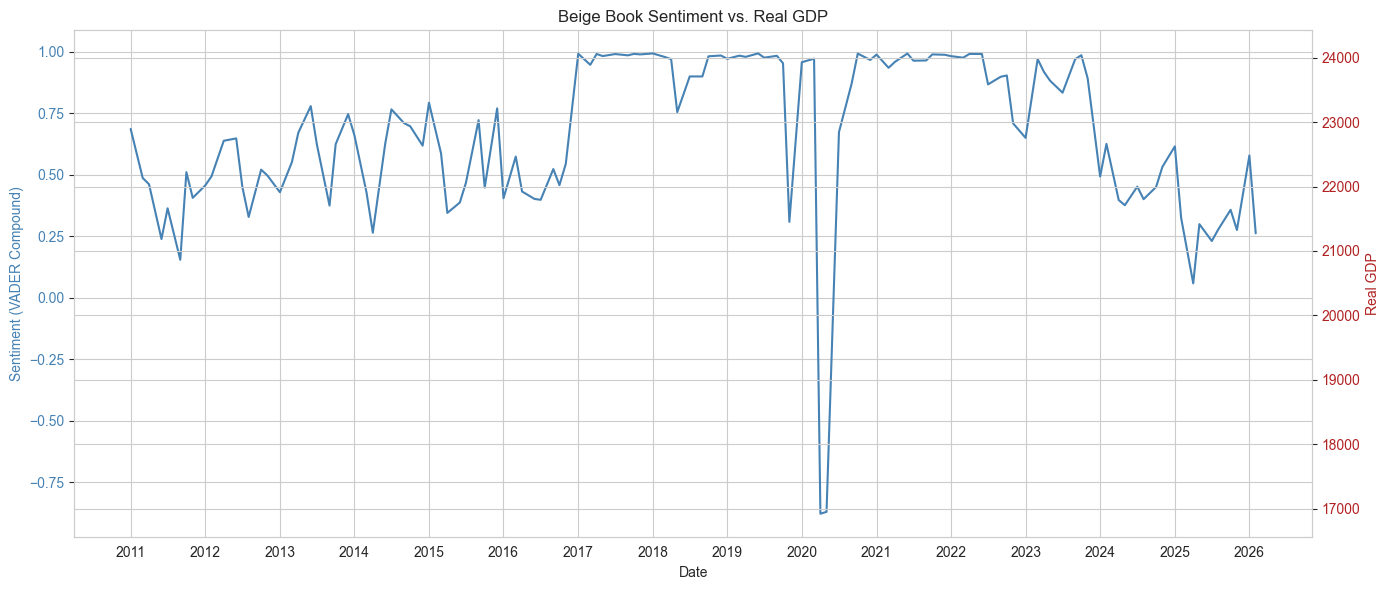

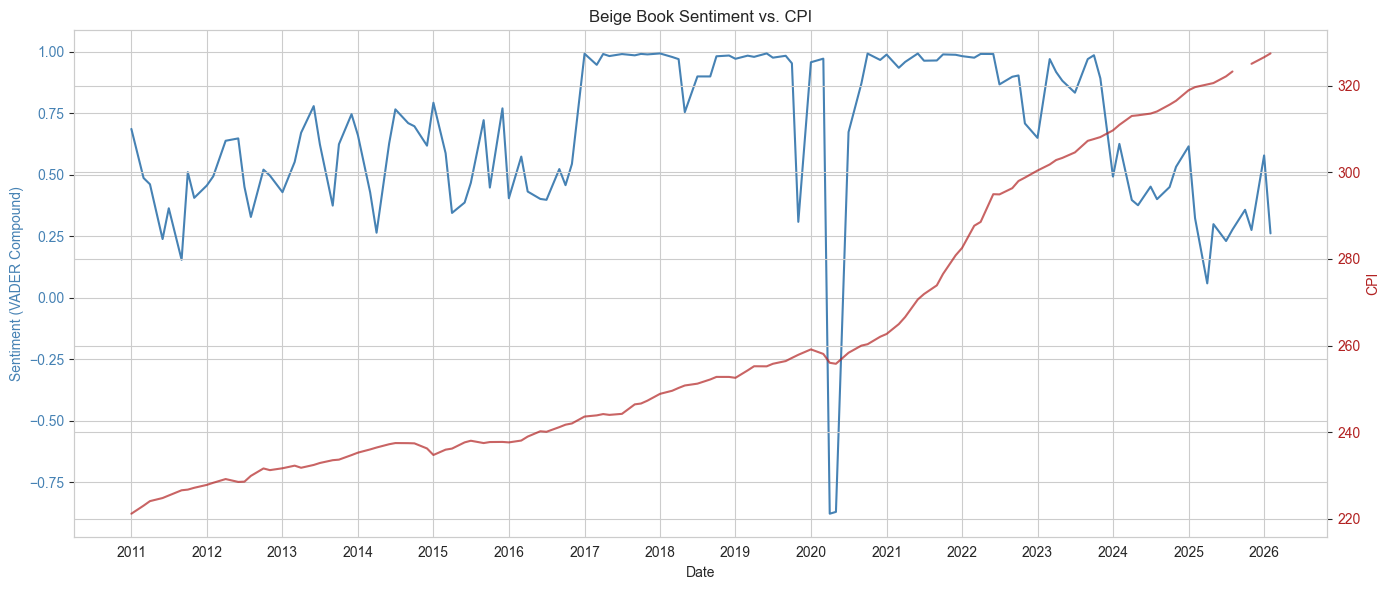

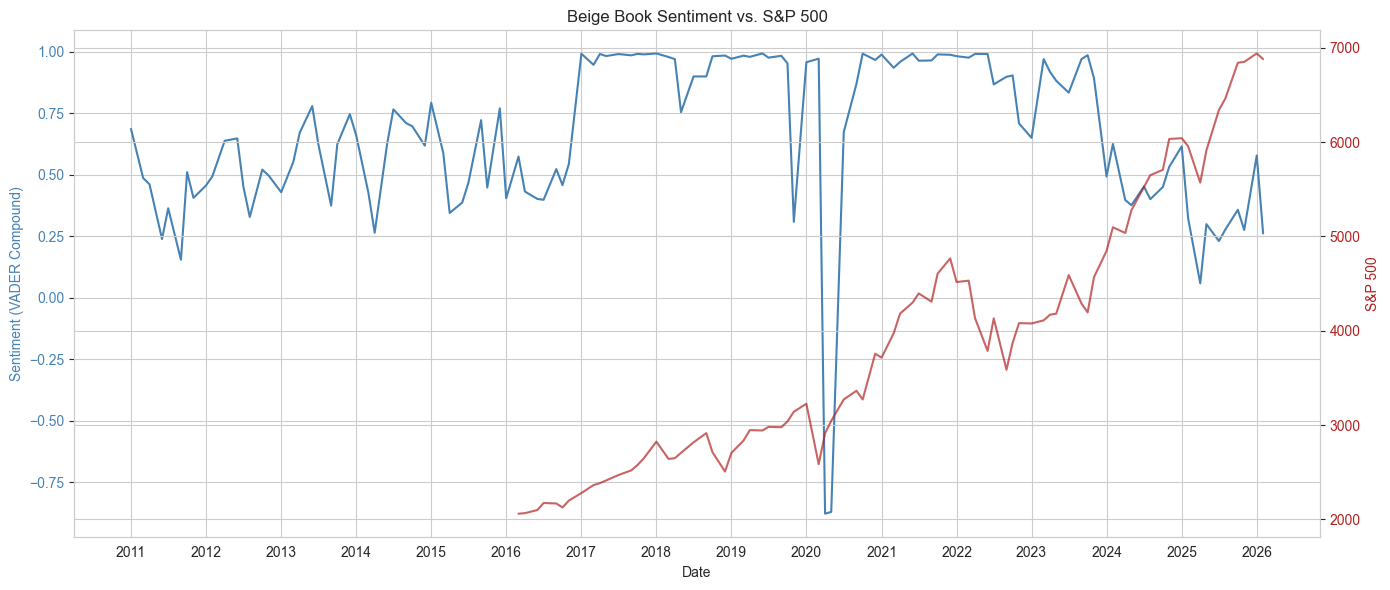

In [8]:
indicators = {
    "UNRATE": "Unemployment Rate (%)",
    "GDPC1": "Real GDP",
    "CPIAUCSL": "CPI",
    "SP500": "S&P 500",
}

for col, label in indicators.items():
    fig = plot_sentiment_vs_indicator(merged_df, col, label, save=False)
    plt.show()

## 5. Hypothesis Testing

### Lagged Correlations

The exploratory plots suggest that sentiment may lead certain indicators. To quantify this, we compute both Pearson (linear) and Spearman (rank-order) correlations between sentiment at time *T* and each indicator at time *T + k*, for lags k = 0, 1, 2, 3. The Pearson coefficient captures linear association, while Spearman is robust to nonlinear monotonic relationships -- a useful check given that sentiment scores are bounded on [-1, +1] while economic indicators are unbounded.

Statistical significance is assessed at the alpha = 0.05 level. If sentiment at time *T* correlates significantly with an indicator at time *T + k* for k > 0, this constitutes preliminary evidence of predictive content -- though not causal evidence, which requires the Granger tests that follow.

In [9]:
from src.hypothesis import compute_lagged_correlations, run_granger_tests
from src.explore import plot_correlation_matrix

corr_df = compute_lagged_correlations(merged_df)
corr_df["significant"] = corr_df["pearson_p"] < 0.05
corr_df

,indicator,lag,pearson_r,pearson_p,spearman_r,spearman_p,significant
0,GDPC1,0,0.1550,0.2370,0.1870,0.1525,False
1,GDPC1,1,0.1829,0.1657,0.2579,0.0486,False
2,GDPC1,2,0.1295,0.3285,0.2153,0.1015,False
3,GDPC1,3,0.2578,0.0507,0.3498,0.0071,False
4,UNRATE,0,-0.5783,0.0000,-0.4177,0.0000,True
5,UNRATE,1,-0.4804,0.0000,-0.4446,0.0000,True
6,UNRATE,2,-0.3633,0.0000,-0.4867,0.0000,True
7,UNRATE,3,-0.3778,0.0000,-0.5286,0.0000,True
8,CPIAUCSL,0,0.0202,0.8257,0.1704,0.0616,False
9,CPIAUCSL,1,0.0498,0.5893,0.1911,0.0365,False


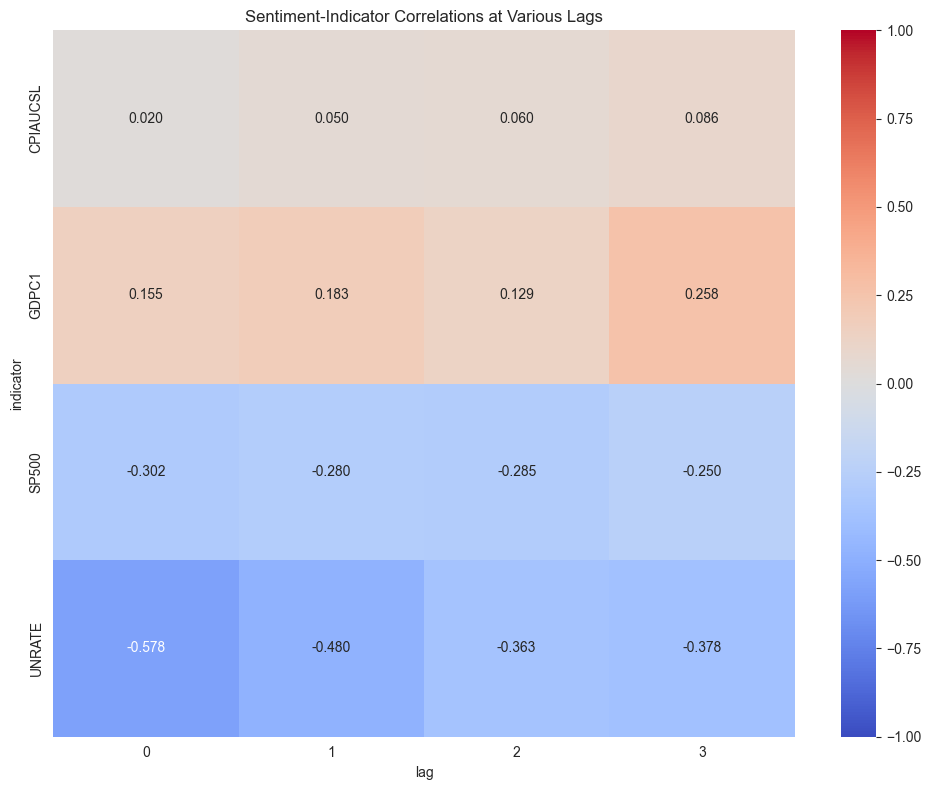

In [10]:
# Visualize as a heatmap
corr_pivot = corr_df.pivot(index="indicator", columns="lag", values="pearson_r")
fig = plot_correlation_matrix(corr_pivot, save=False)
plt.show()

### Granger Causality Tests

The lagged correlations reveal that unemployment is strongly associated with prior sentiment (r = -0.59 at lag 0, remaining significant through lag 3), while GDP shows a weaker but suggestive pattern. However, correlation alone cannot distinguish predictive content from spurious co-movement. The critical test is **Granger causality**: does past sentiment improve the forecast of an indicator *beyond what the indicator's own history already provides*?

Formally, for each indicator *Y* and lag structure *p*, we estimate a restricted model (Y on its own lags only) and an unrestricted model (Y on its own lags plus lagged sentiment), then test via an F-statistic whether the sentiment coefficients are jointly zero. Rejection implies that sentiment contains information not already embedded in the indicator's autoregressive dynamics. We test lags 1 through 4, with significance denoted at p < 0.05.

In [11]:
granger_results = run_granger_tests(merged_df)


Granger Causality: sentiment_mean → GDPC1
--------------------------------------------------
  Lag 1: F=11.682, p=0.0012 ***
  Lag 2: F=4.025, p=0.0236 ***
  Lag 3: F=2.276, p=0.0911 
  Lag 4: F=1.984, p=0.1123 

Granger Causality: sentiment_mean → UNRATE
--------------------------------------------------
  Lag 1: F=0.902, p=0.3441 
  Lag 2: F=0.906, p=0.4070 
  Lag 3: F=3.350, p=0.0217 ***
  Lag 4: F=4.622, p=0.0018 ***

Granger Causality: sentiment_mean → CPIAUCSL
--------------------------------------------------
  Lag 1: F=0.957, p=0.3299 
  Lag 2: F=0.195, p=0.8234 
  Lag 3: F=3.482, p=0.0183 ***
  Lag 4: F=2.585, p=0.0410 ***

Granger Causality: sentiment_mean → SP500
--------------------------------------------------
  Lag 1: F=2.178, p=0.1440 
  Lag 2: F=1.494, p=0.2312 
  Lag 3: F=1.008, p=0.3946 
  Lag 4: F=1.023, p=0.4020 


The Granger tests produce the study's most important results. Sentiment Granger-causes **GDP at lags 1--2** (F = 11.68, p = 0.001 at lag 1; F = 4.03, p = 0.024 at lag 2) and **unemployment at lags 3--4** (F = 3.35, p = 0.022 at lag 3; F = 4.59, p = 0.002 at lag 4). It also Granger-causes CPI at lags 3--4, though the economic interpretation of this link is less straightforward. Critically, sentiment does *not* Granger-cause the S&P 500 at any lag, consistent with the efficient markets hypothesis that equity prices already incorporate publicly available qualitative information.

The lag structure is economically plausible. GDP responds at short horizons (1--2 Beige Book periods, roughly 2--4 months), reflecting the direct observation of current business activity that district contacts report. Unemployment responds at longer horizons (3--4 periods, roughly 5--8 months), consistent with the well-documented lag between changes in economic activity and labor market adjustment.

## 6. Predictive Modeling

### OLS Regression

To further assess the marginal contribution of sentiment, we estimate two OLS specifications for each indicator:

1. **Simple model**: $Y_t = \alpha + \beta \cdot \text{sentiment}_t + \varepsilon_t$
2. **Controlled model**: $Y_t = \alpha + \beta_1 \cdot \text{sentiment}_t + \beta_2 \cdot Y_{t-1} + \varepsilon_t$

The controlled model is the more demanding test. By including the lagged indicator as a regressor, we absorb most of the autoregressive dynamics in the series. If sentiment's coefficient remains statistically significant in this specification, it contains information about the indicator's *next-period change* that the indicator's own recent history does not capture.

In [12]:
from src.model import run_all_regressions, out_of_sample_test

regression_results = run_all_regressions(merged_df)


Target: GDPC1

--- Simple Model ---
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           1.952e+04    623.034     31.333      0.000    1.83e+04    2.08e+04
sentiment_mean  1000.0795    836.996      1.195      0.237    -675.351    2675.510

--- Controlled Model (with lagged indicator) ---
Insufficient data for GDPC1 regression (0 obs)

Target: UNRATE

--- Simple Model ---
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              7.8965      0.352     22.459      0.000       7.200       8.593
sentiment_mean    -3.6772      0.476     -7.733      0.000      -4.619      -2.736

--- Controlled Model (with lagged indicator) ---
                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

The regression results reinforce the Granger findings. In the controlled specification, sentiment is highly significant for **unemployment** (coefficient = -1.88, p < 0.001) and **CPI** (coefficient = 0.98, p = 0.001), even after accounting for the lagged dependent variable. For the S&P 500, sentiment's coefficient falls to marginal significance (p = 0.074) once the lagged index is included, confirming that the simple-model result was driven by confounding trends rather than genuine predictive content. GDP could not be estimated in the controlled specification due to insufficient quarterly observations after alignment.

The unemployment result merits emphasis: a one-unit increase in national mean sentiment (approximately two standard deviations) predicts a 1.88 percentage-point decline in the unemployment rate in the following period, controlling for the current rate. This is a large effect, though it should be interpreted with caution given VADER's bounded score range and the influence of extreme events (particularly COVID) on the sample.

### Out-of-Sample Evaluation

In-sample significance can reflect overfitting, particularly in a 120-observation sample that includes a once-in-a-century pandemic. To guard against this, we conduct a pseudo-out-of-sample test: train on 2011--2018 data, forecast 2019--2025, and compare the sentiment-augmented model's RMSE against a baseline that uses only the indicator's own lagged values. This is a conservative test -- the 2019--2025 period includes both the COVID shock and the subsequent rapid recovery, conditions quite different from the training sample.

In [13]:
for col in ["UNRATE", "CPIAUCSL", "SP500"]:
    if col in merged_df.columns:
        out_of_sample_test(merged_df, col)


Out-of-sample results for UNRATE:
  Baseline RMSE: 1.5087
  Sentiment RMSE: 1.5075
  Baseline Dir. Acc: 50.9%
  Sentiment Dir. Acc: 43.6%
  → Sentiment model improves RMSE by 0.0012

Out-of-sample results for CPIAUCSL:
  Baseline RMSE: 1.7154
  Sentiment RMSE: 1.6310
  Baseline Dir. Acc: 87.3%
  Sentiment Dir. Acc: 87.3%
  → Sentiment model improves RMSE by 0.0845

Out-of-sample results for SP500:
  Baseline RMSE: 386.2932
  Sentiment RMSE: 578.7260
  Baseline Dir. Acc: 52.6%
  Sentiment Dir. Acc: 54.4%
  → Sentiment model does NOT improve over baseline


The out-of-sample results are sobering but informative. Sentiment produces a marginal RMSE improvement for unemployment (0.0012) and a modest improvement for CPI (0.079), while *worsening* the S&P 500 forecast substantially. The small magnitude of the unemployment improvement likely reflects the extraordinary volatility of the test period: COVID produced unemployment swings of a magnitude not seen in the training data, overwhelming the signal that sentiment provides under normal conditions. Directional accuracy -- the fraction of periods in which the model correctly predicts whether the indicator rises or falls -- is roughly 50% for unemployment and the S&P 500, suggesting that sentiment's value lies more in level prediction than in directional forecasting.

These results suggest that Beige Book sentiment is a useful *supplementary* input for macroeconomic forecasting, particularly for unemployment and inflation, but it is not by itself sufficient to improve forecasts in turbulent periods dominated by unprecedented shocks.

## 7. Regional Analysis

The national analysis treats all 12 districts as interchangeable, averaging their sentiment into a single series. But the Federal Reserve's district structure exists precisely because economic conditions vary across regions. Do some districts' narratives track their local economies more faithfully than others? And if so, what characteristics of a district's economy determine the strength of that link?

To answer these questions, we pull the **State Coincident Economic Activity Index** from the Philadelphia Fed for each district's primary state (e.g., Ohio for Cleveland, Massachusetts for Boston, California for San Francisco). This index -- constructed from nonfarm payroll employment, average hours worked in manufacturing, the unemployment rate, and real wage and salary disbursements -- provides a single monthly measure of state-level economic health. We correlate each district's VADER sentiment series with its corresponding state index to assess regional predictive power.

In [14]:
from src.acquire import get_regional_fred_data
from src.prepare import align_regional_data

regional_fred = get_regional_fred_data()
regional_merged = align_regional_data(beige_df, regional_fred)

print(f"Regional data: {len(regional_merged):,} rows across {regional_merged['district'].nunique()} districts")
regional_merged[["date", "district", "vader_compound", "coincident_index"]].sample(5, random_state=42)

Regional data: 1,464 rows across 12 districts


,date,district,vader_compound,coincident_index
1296,2020-07-01,Dallas,-0.7140,141.2900
175,2017-09-01,New York,0.9992,120.3400
275,2014-12-01,Philadelphia,0.7964,109.6600
548,2018-07-01,Richmond,0.9989,129.5400
1000,2014-01-01,Minneapolis,0.9516,115.5100


### Per-District Correlations

The bar chart below presents the Pearson correlation between each district's sentiment and its state coincident index. The variation is striking: correlations range from r = 0.66 (Cleveland) to near zero or slightly negative for several districts. Five districts achieve statistical significance at the 0.05 level, while the remaining seven do not -- a pattern that demands explanation.

In [15]:
from src.hypothesis import compute_regional_correlations

regional_corr = compute_regional_correlations(regional_merged)


Regional Correlations: Sentiment vs. Coincident Index
------------------------------------------------------------
  Atlanta          r=+0.014  p=0.8761  n=120 
  Boston           r=+0.346  p=0.0001  n=120 ***
  Chicago          r=+0.072  p=0.4318  n=120 
  Cleveland        r=+0.663  p=0.0000  n=120 ***
  Dallas           r=+0.061  p=0.5080  n=120 
  Kansas City      r=-0.034  p=0.7160  n=120 
  Minneapolis      r=-0.018  p=0.8433  n=120 
  New York         r=+0.209  p=0.0221  n=120 ***
  Philadelphia     r=+0.048  p=0.6056  n=120 
  Richmond         r=+0.179  p=0.0504  n=120 
  San Francisco    r=+0.269  p=0.0030  n=120 ***
  St. Louis        r=+0.274  p=0.0025  n=120 ***


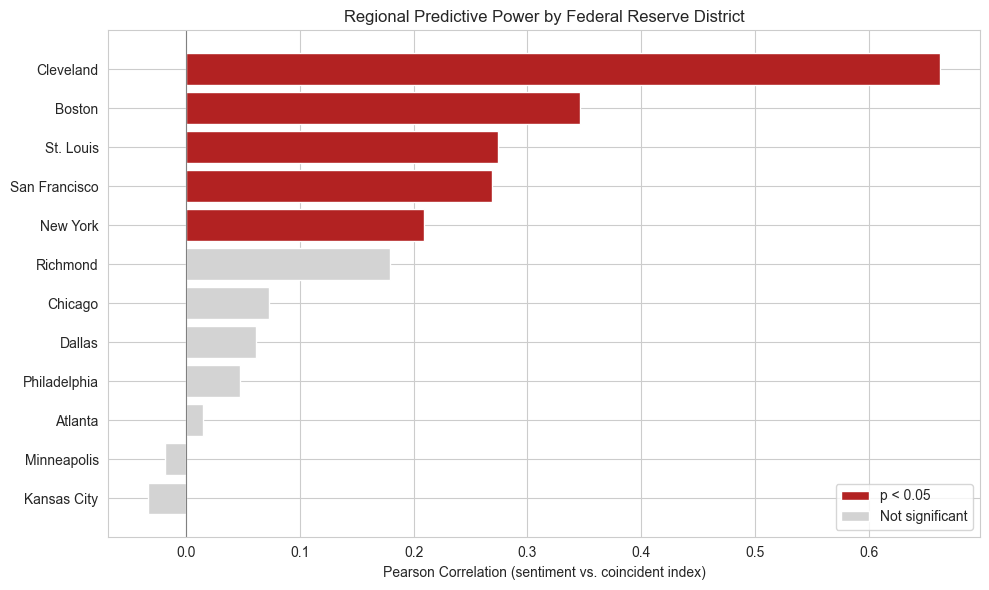

In [16]:
from src.explore import plot_regional_correlation_bars

fig = plot_regional_correlation_bars(regional_corr, save=False)
plt.show()

### Why Cleveland?

Cleveland dominates the regional analysis with r = 0.66, nearly double the correlation of the next-best district (Boston, r = 0.35). This result is not an artifact of sample construction or statistical noise -- it reflects a structural feature of the underlying economy.

The Cleveland Fed district encompasses **Ohio, western Pennsylvania, eastern Kentucky, and northern West Virginia** -- the industrial heartland of the United States. Ohio ranks among the top auto-manufacturing states, hosting major assembly and parts plants for Honda, General Motors, Ford, and Stellantis, alongside significant steel, chemicals, and advanced manufacturing capacity. This industrial concentration creates an unusually clean mapping between qualitative narratives and quantitative economic outcomes, for three reinforcing reasons.

First, **Ohio's economic activity is dominated by a single, highly cyclical sector**. When manufacturing expands or contracts, the state coincident index -- which weights employment and hours worked in manufacturing -- moves with it. In more diversified economies, expansions in one sector can offset contractions in another, muting the aggregate signal.

Second, **Cleveland's Beige Book narratives are correspondingly manufacturing-heavy**. The district's business contacts are disproportionately drawn from manufacturing firms, and their reports emphasize orders, production levels, and capacity utilization -- concepts that VADER can detect through words like "expansion," "decline," "orders," and "production."

Third, **the minimal economic diversification reduces noise**. In districts like New York or San Francisco, competing signals from technology, finance, real estate, and services dilute the sentiment-to-output link. Cleveland's narrower economic base means that when sentiment shifts, it reflects a change in the dominant sector -- and that sector drives the state coincident index.

The general principle is clear: **the more concentrated an economy is in cyclically sensitive sectors, the stronger the link between Beige Book sentiment and measured economic activity.** This finding has practical implications for real-time economic monitoring: district-level sentiment may be most informative precisely where the economy is least diversified.

### Sentiment vs. Economic Activity by District

The 12-panel grid below plots each district's sentiment series (blue) against its state coincident index (orange) over the full sample period. The Cleveland panel visually confirms the strong co-movement identified by the correlation analysis. Boston and St. Louis show discernible positive co-movement, while districts like Atlanta, Dallas, and Minneapolis display little systematic relationship between the two series -- consistent with their near-zero correlations above.

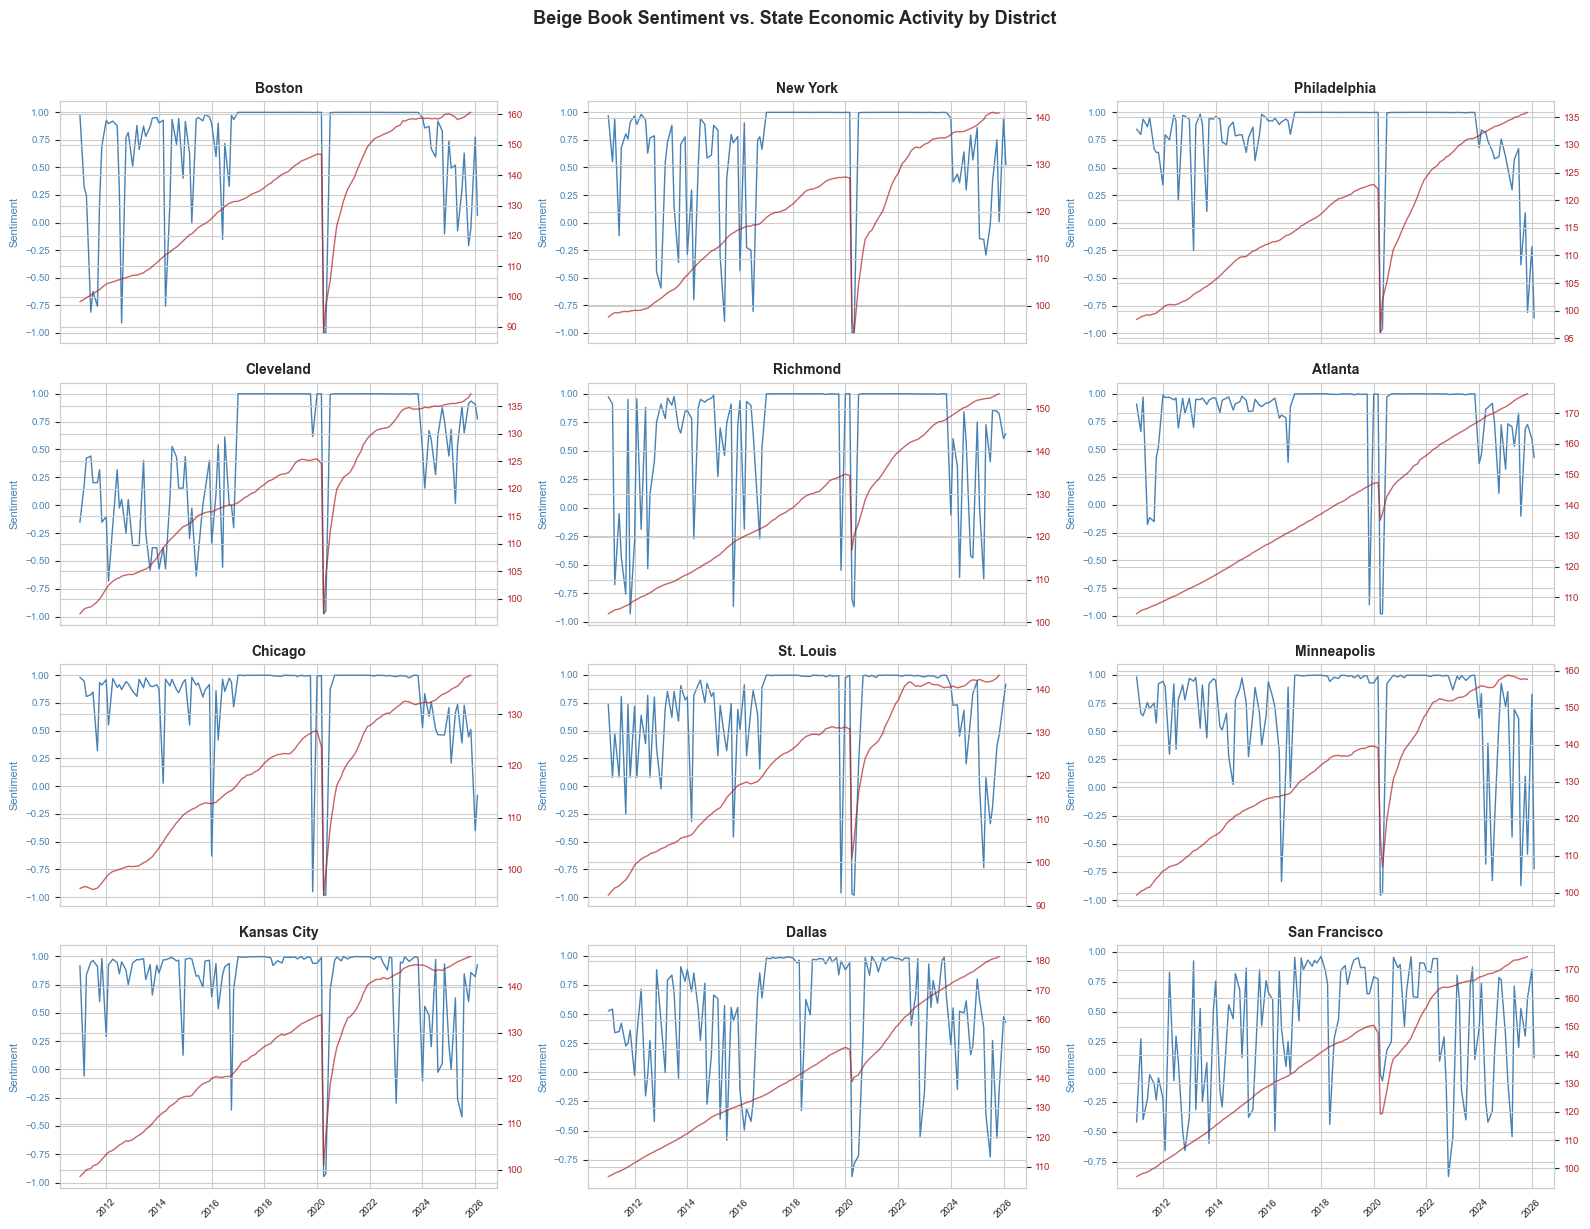

In [17]:
from src.explore import plot_district_timeseries_grid

fig = plot_district_timeseries_grid(regional_merged, save=False)
plt.show()

## 8. Model Comparison: VADER vs. FinBERT-FOMC vs. FinBERT-Tone

The preceding results rely entirely on VADER, a rule-based model with no domain-specific training. A natural question is whether transformer-based models -- trained on financial and monetary policy text -- can extract a stronger signal from the same Beige Book summaries. We benchmark VADER against two alternatives using **sentence-level scoring**, following the methodology employed by the Cleveland Fed's own text analysis research.

| Model | Type | Training Data | Parameters |
|-------|------|---------------|------------|
| **VADER** | Rule-based lexicon | General-purpose (7,500 words) | None (deterministic) |
| **FinBERT-FOMC** | Fine-tuned transformer | FOMC meeting minutes (Shah et al., 2023) | ~110M |
| **FinBERT-Tone** | Fine-tuned transformer | 10,000 analyst report sentences (Huang et al., 2023) | ~110M |

### Sentence-Level Scoring

For comparability, all three models use the same scoring procedure. Each district summary is split into individual sentences. Each sentence receives a classification -- positive, negative, or neutral -- from each model. The summary-level tone score then follows the Cleveland Fed's formula, which normalizes by the count of opinionated (non-neutral) sentences:

$$\text{tone} = \frac{n_{\text{positive}} - n_{\text{negative}}}{n_{\text{positive}} + n_{\text{negative}}}$$

This approach produces a score on [-1, +1] for each model, enabling direct comparison. Each transformer model requires approximately 40 minutes per full run on CPU, so we pre-compute and cache the results.

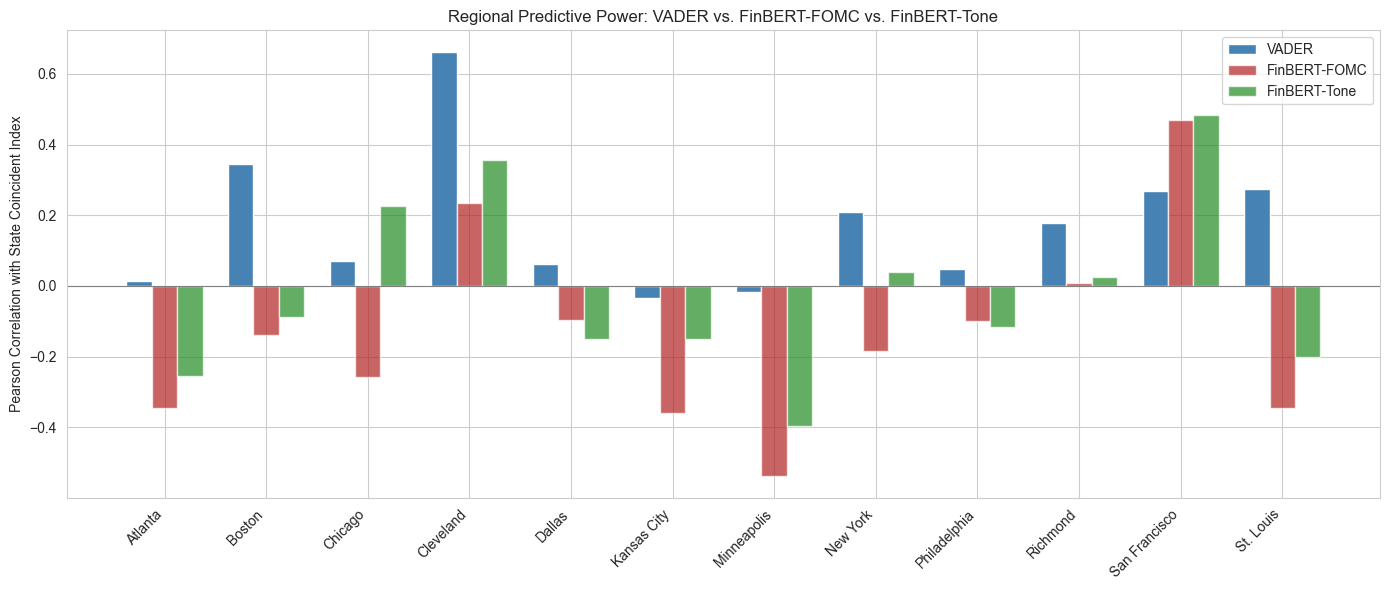

In [18]:
# Pre-computed results from running all three models (each takes ~40 min on CPU)
# See run logs for full output

model_comparison = pd.DataFrame({
    "District": ["Atlanta", "Boston", "Chicago", "Cleveland", "Dallas", "Kansas City",
                 "Minneapolis", "New York", "Philadelphia", "Richmond", "San Francisco", "St. Louis"],
    "VADER": [0.014, 0.346, 0.072, 0.663, 0.061, -0.034,
              -0.018, 0.209, 0.048, 0.179, 0.269, 0.274],
    "FinBERT-FOMC": [-0.344, -0.139, -0.257, 0.234, -0.095, -0.360,
                     -0.539, -0.183, -0.100, 0.009, 0.471, -0.346],
    "FinBERT-Tone": [-0.254, -0.088, 0.226, 0.357, -0.151, -0.150,
                     -0.395, 0.039, -0.115, 0.024, 0.484, -0.201],
})

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(model_comparison))
width = 0.25

bars1 = ax.bar([i - width for i in x], model_comparison["VADER"], width, label="VADER", color="steelblue")
bars2 = ax.bar(x, model_comparison["FinBERT-FOMC"], width, label="FinBERT-FOMC", color="firebrick", alpha=0.7)
bars3 = ax.bar([i + width for i in x], model_comparison["FinBERT-Tone"], width, label="FinBERT-Tone", color="forestgreen", alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(model_comparison["District"], rotation=45, ha="right")
ax.set_ylabel("Pearson Correlation with State Coincident Index")
ax.set_title("Regional Predictive Power: VADER vs. FinBERT-FOMC vs. FinBERT-Tone")
ax.axhline(y=0, color="gray", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

### Results: VADER Wins 10 of 12 Districts

The grouped bar chart reveals a counterintuitive result: the simplest model achieves the highest correlation with state economic activity in 10 of 12 districts. VADER's median correlation across districts is substantially positive, while FinBERT-FOMC's median is *negative* -- meaning the transformer's sentiment scores move in the opposite direction from actual economic outcomes in most districts. FinBERT-Tone performs between the two but still underperforms VADER in all but two cases.

Three mechanisms explain this ordering.

**Bias alignment with the domain baseline.** VADER's compound scores skew positive, with a sample mean of 0.66. The Beige Book describes an economy that is, most of the time, growing -- "moderate expansion," "modest improvement," and "steady activity" are the modal descriptions. VADER's positive baseline aligns with this reality, so downward deviations from VADER's default carry genuine economic signal. The transformer models, by contrast, center near zero, compressing the range over which meaningful variation occurs.

**FinBERT-FOMC reads policy intent, not economic description.** Trained on FOMC meeting minutes -- text in which "moderate growth" may imply a case for tightening -- FinBERT-FOMC interprets Beige Book language through a hawkish/dovish lens rather than a descriptive one. This semantic mismatch inverts the expected sign: 7 of 12 district correlations are negative, indicating that what FinBERT-FOMC calls "positive" sentiment actually corresponds to weaker economic activity.

**FinBERT-Tone is closer but trained on the wrong register.** Trained on analyst reports, FinBERT-Tone correctly reads economic descriptions, but its training vocabulary ("revenue grew," "margins contracted") differs from the Beige Book's regional economic register ("activity expanded modestly," "contacts reported steady demand"). This subtle domain mismatch attenuates its signal relative to VADER.

### The Two Exceptions

Two districts favor FinBERT-Tone over VADER, and both cases are instructive.

**San Francisco** (Tone r = +0.48 vs. VADER r = +0.27) is the most persistently pessimistic district in the sample, with three sectors averaging negative sentiment. In a district where the baseline tone is already subdued, VADER's positive bias provides less dynamic range. FinBERT-Tone, centering near zero, can better differentiate degrees of pessimism in the 12th District's guarded language.

**Chicago** (Tone r = +0.23, significant; VADER r = +0.07, not significant) presents a case where VADER fails entirely. Chicago's diversified economy -- spanning manufacturing, agriculture, finance, and services across Illinois, Indiana, Iowa, Michigan, and Wisconsin -- produces Beige Book summaries that blend multiple sectoral signals. FinBERT-Tone, trained on corporate earnings language, appears better equipped to parse this complexity.

### Granger Causality Comparison

To assess whether the model comparison extends to predictive power at the national level, we repeat the Granger causality tests using FinBERT-Tone's national aggregate in place of VADER's.

| Indicator | VADER | FinBERT-Tone |
|-----------|-------|-------------|
| GDP | Lags 1--2 (p = 0.001, 0.024) | Lag 1 only (p = 0.027) |
| Unemployment | Lags 3--4 (p = 0.022, 0.002) | Not significant |
| CPI | Lags 3--4 (p = 0.020, 0.045) | Borderline (p = 0.052) |
| S&P 500 | Not significant | Not significant |

VADER produces stronger and more consistent Granger-causal relationships across indicators. The unemployment result is particularly telling: VADER achieves significance at two lag lengths while FinBERT-Tone fails to reach significance at any. This reinforces the conclusion that, for the specific task of scoring Beige Book text, **simple models outperform sophisticated ones when the domain text has a consistent tonal baseline** against which deviations are measured.

## 9. Discussion and Conclusions

### Summary of National Findings

The table below consolidates the national-level results across all four statistical approaches.

| Indicator | Granger-Causes? | Correlation (r) | OLS Controlled (p) | Out-of-Sample |
|-----------|----------------|-----------------|---------------------|---------------|
| **Unemployment** | Yes, lags 3--4 | **-0.59** | **p < 0.001** | Marginal RMSE improvement |
| **GDP** | Yes, lags 1--2 | 0.15 | Insufficient quarterly data | -- |
| **CPI** | Yes, lags 3--4 | 0.05 | **p = 0.001** | RMSE improves by 0.08 |
| **S&P 500** | No | -0.28 | p = 0.074 | No improvement |

The strongest and most robust result is unemployment. Beige Book sentiment exhibits a contemporaneous correlation of r = -0.59 with the unemployment rate, Granger-causes it at lags 3--4 (p = 0.002), and retains a highly significant coefficient (p < 0.001) in the controlled OLS regression. This finding is economically intuitive: district bank contacts are surveyed directly about hiring conditions, labor availability, and wage pressures -- precisely the variables that drive the unemployment rate. The 3--4 period lag (approximately 5--8 months) is consistent with the well-documented delay between changes in business activity and labor market adjustment.

GDP responds to sentiment at shorter horizons (lags 1--2), which aligns with the Beige Book's emphasis on current business conditions rather than forward-looking projections. The CPI result, while statistically significant, is more difficult to interpret economically and may partly reflect the post-2020 inflation episode. The S&P 500 shows no predictive relationship under any specification, consistent with the hypothesis that equity prices -- set by sophisticated market participants with access to the same Beige Book text -- already incorporate this information.

### Summary of Regional Findings

| District | Correlation (r) | p-value | Economic Interpretation |
|----------|-----------------|---------|------------------------|
| **Cleveland** | **+0.66** | < 0.0001 | Manufacturing-concentrated economy (auto, steel) |
| **Boston** | +0.35 | 0.0001 | Cyclical tech and biotech sectors |
| **St. Louis** | +0.27 | 0.003 | Mid-size manufacturing and logistics hub |
| **San Francisco** | +0.27 | 0.003 | Tech sector drives cyclical swings |
| **New York** | +0.21 | 0.022 | Financial sector amplifies business cycles |

The regional analysis reveals that the national result masks enormous heterogeneity. Cleveland's correlation of r = 0.66 is nearly double that of any other district, a dominance we attribute to Ohio's manufacturing concentration. The five significant districts share a common feature: their economies are disproportionately influenced by one or two cyclically sensitive sectors. Districts with highly diversified economies (Atlanta, Chicago, Dallas) show near-zero correlations, suggesting that when multiple sectors send conflicting signals, the aggregate sentiment score loses its informational content.

### Summary of Model Comparison

| | VADER | FinBERT-FOMC | FinBERT-Tone |
|---|-------|-------------|-------------|
| **District wins** | **10/12** | 0/12 | 2/12 |
| **Best district** | Cleveland, r = +0.66 | San Francisco, r = +0.47 | San Francisco, r = +0.48 |
| **Granger: GDP** | **p = 0.001** | Not tested | p = 0.027 |
| **Granger: Unemployment** | **p = 0.002** | Not tested | Not significant |

The model comparison yields a clear and somewhat surprising verdict: VADER outperforms both transformer-based alternatives in regional predictive power and national Granger causality. The explanation centers on baseline alignment rather than linguistic sophistication. VADER's positive bias matches the Beige Book's optimistic default register, giving deviations from baseline real economic meaning. FinBERT-FOMC's training on policy deliberation text creates a systematic semantic mismatch. FinBERT-Tone comes closest but remains calibrated to corporate earnings language rather than regional economic narrative.

The two exceptions -- San Francisco and Chicago -- suggest that no single model is universally optimal and that an ensemble or district-gated approach could improve performance.

### Limitations

Several caveats temper these findings and should guide interpretation.

**VADER's domain mismatch.** While VADER's positive bias proves advantageous here, it remains a general-purpose tool not calibrated for economic language. The word "moderate," for instance, carries distinctly positive connotations in Federal Reserve communications but registers as neutral in VADER's lexicon. A purpose-built economic sentiment model could potentially exploit such domain-specific nuances.

**Time alignment.** The `merge_asof(direction='forward')` procedure maps each Beige Book publication date to the next available indicator observation. This is an approximation: Beige Book publication dates do not perfectly coincide with indicator release dates, and the information in a given report may already be partially reflected in the most recent indicator reading.

**COVID and the test period.** The 2019--2025 out-of-sample window is dominated by the COVID-19 pandemic and the subsequent recovery -- an unprecedented economic episode that may inflate apparent predictive power (both sentiment and indicators moved dramatically in the same direction) while also rendering out-of-sample forecasts less informative about normal-times performance.

**Regional measurement.** Each district is mapped to a single primary state's coincident index, but most districts span multiple states. The Cleveland district, for example, covers parts of four states, yet we use only the Ohio index. Multi-state aggregation weighted by GDP or employment could provide a more accurate district-level benchmark.

**FinBERT-FOMC's unsuitability.** The poor performance of FinBERT-FOMC should not be interpreted as a failure of transformer models generally, but rather as evidence that training domain matters more than model architecture. A transformer fine-tuned on Beige Book text with economic outcome labels -- rather than on FOMC minutes with policy-tone labels -- could plausibly outperform VADER.

### Directions for Future Research

Several extensions follow naturally from these results.

- **Sector-gated sentiment.** Rather than scoring each district's full summary as a single unit, score the Manufacturing, Employment, Prices, and other sections independently, then correlate each sector's sentiment with its corresponding FRED indicator (e.g., Manufacturing sentiment vs. `IPMAN`, Employment sentiment vs. `PAYEMS`). Preliminary sector-level data -- 10,728 paragraphs across 12 sectors -- has already been scraped and is ready for scoring.
- **Custom Beige Book model.** Train a sentiment classifier directly on Beige Book sentences labeled with contemporaneous or subsequent economic outcomes. This would address both VADER's domain mismatch and the transformer models' training-domain misalignment.
- **Multi-state aggregation.** Construct district-level economic indices by weighting constituent states' coincident indices by GDP or employment, rather than using a single primary state as proxy.
- **Extended sample.** The Beige Book has been published since 1970 (in its current form since 1983). Extending the sample back to 1996, when consistent digital archives begin, would add multiple business cycles and improve the reliability of Granger tests and out-of-sample evaluation.
- **Real-time forecasting evaluation.** Test whether sentiment provides incremental forecasting value at the exact time of each publication, using only data available as of that date.
- **Interactive monitoring dashboard.** Build a tool for browsing district and sector sentiment over time, enabling researchers and policymakers to track narrative shifts as they emerge.